# 04. Weather (BoM proxy) + Telemetry/TIRTL EDA (sudheer)
**Team B - Traffic Volumes & Parking | Sprint 1**

The last two datasets from the ChatGPT-recommended list: weather as a confounding factor for
traffic/parking demand, and Telemetry/TIRTL as a complementary vehicle-speed and classification
source alongside SCATS.

1. **Weather (BoM proxy)** - the official Bureau of Meteorology Climate Data Online portal returns
   `HTTP 403` for scripted requests, so this uses the free
   [Open-Meteo Historical Weather API](https://open-meteo.com/) for Melbourne CBD coordinates as a
   documented substitute (see `00_data_ingestion.ipynb`).
2. **Telemetry & TIRTL Traffic Counts** (Transport Victoria) - 15-minute vehicle volume, speed and
   classification counts from a statewide network of strategic-road sensors.


In [1]:
import glob
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RAW_DIR = Path("../../../data/raw")
PROCESSED_DIR = Path("../../../data/processed")
plt.rcParams["figure.figsize"] = (10, 4)


## 1. Weather (Open-Meteo, Melbourne CBD)

In [2]:
weather = pd.read_csv(RAW_DIR / "melbourne_cbd_weather_hourly.csv", parse_dates=["time"])
print(f"{len(weather)} hourly weather rows: {weather['time'].min()} to {weather['time'].max()}")
weather.describe()


1080 hourly weather rows: 2026-07-01 00:00:00 to 2026-08-14 23:00:00


,time,temperature_2m,precipitation,wind_speed_10m
count,1080,1080.000000,1080.000000,1080.000000
mean,2026-07-23 11:29:59.999999744,10.302685,0.095370,10.987037
min,2026-07-01 00:00:00,2.400000,0.000000,0.000000
25%,2026-07-12 05:45:00,8.500000,0.000000,6.500000
50%,2026-07-23 11:30:00,10.500000,0.000000,11.000000
75%,2026-08-03 17:15:00,12.200000,0.000000,14.700000
max,2026-08-14 23:00:00,16.600000,6.100000,27.900000
std,NaN,2.848384,0.420795,5.540965


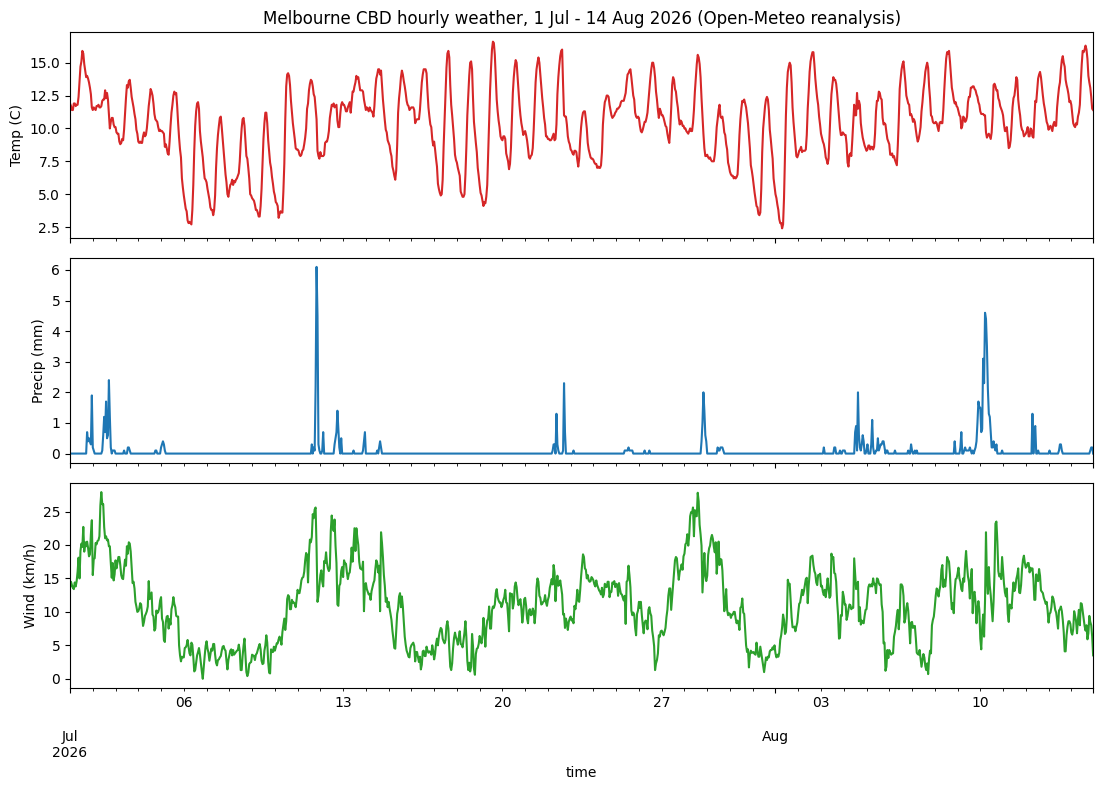

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
weather.set_index("time")["temperature_2m"].plot(ax=axes[0], color="tab:red")
axes[0].set_ylabel("Temp (C)")
weather.set_index("time")["precipitation"].plot(ax=axes[1], color="tab:blue")
axes[1].set_ylabel("Precip (mm)")
weather.set_index("time")["wind_speed_10m"].plot(ax=axes[2], color="tab:green")
axes[2].set_ylabel("Wind (km/h)")
axes[0].set_title("Melbourne CBD hourly weather, 1 Jul - 14 Aug 2026 (Open-Meteo reanalysis)")
plt.tight_layout()
plt.show()


In [4]:
rainy_hours = (weather["precipitation"] > 0.1).sum()
print(f"Hours with measurable rain (>0.1mm): {rainy_hours} / {len(weather)} ({rainy_hours/len(weather):.1%})")
print(f"Mean winter temperature: {weather['temperature_2m'].mean():.1f}C")


Hours with measurable rain (>0.1mm): 115 / 1080 (10.6%)
Mean winter temperature: 10.3C


**Finding:** this window covers Melbourne's winter (Jul-Aug), with ~11% of hours showing measurable
rain - a plausible confound for both parking dwell time (people may drive rather than walk/cycle in
poor weather) and cyclist/pedestrian counts. Once the pipeline reaches a real before/after
comparison, matching weather conditions across baseline and post-intervention windows (or including
`precipitation`/`temperature_2m` as covariates) will help separate the intervention's effect from
seasonal noise.


## 2. TIRTL Traffic Counts (inner-Melbourne sites)

In [5]:
tirtl_sites = pd.read_csv(PROCESSED_DIR / "tirtl_inner_melbourne_sites.csv")
print(f"{len(tirtl_sites)} inner-Melbourne TIRTL sites:")
tirtl_sites[["site", "site_description"]]


10 inner-Melbourne TIRTL sites:


,site,site_description
0,115,M1 Before High Street Bridge Inbound (WB)
1,522,Shepherd Bridge Overheight TIRTL
2,524,High Street Onramp Inbound to Monash Fwy (Top)
3,525,High Street Onramp Inbound to Monash Fwy (Mid)
4,526,High Street Onramp Inbound to Monash Fwy (Befo...
5,527,High Street Onramp Inbound to Monash Fwy (Afte...
6,532,Hyde St and York St (NB)
7,533,Hyde St and Berry St (NB)
8,504,M1 West Gate Bridge Inbound (EB)
9,505,M1 West Gate Bridge Outbound (WB)


In [6]:
tirtl_files = sorted(glob.glob(str(RAW_DIR / "tirtl_extracted" / "*.csv")))
inner_site_ids = set(tirtl_sites["site"])

frames = []
for f in tirtl_files:
    df = pd.read_csv(f)
    frames.append(df[df["site"].isin(inner_site_ids)])
tirtl = pd.concat(frames, ignore_index=True)
tirtl["date"] = pd.to_datetime(tirtl["date"])
print(f"TIRTL rows for inner-Melbourne sites: {len(tirtl):,} (from {len(tirtl_files)} daily files)")
tirtl.head()


TIRTL rows for inner-Melbourne sites: 99,525 (from 11 daily files)


,date,time_bin,site,heading,vehicle_class,speed_bin,volume
0,2026-08-01,0:00,504,E,1,55km/hr to < 60km/hr,1
1,2026-08-01,0:00,504,E,1,60km/hr to < 65km/hr,1
2,2026-08-01,0:00,504,E,9,60km/hr to < 65km/hr,1
3,2026-08-01,0:00,504,E,10,60km/hr to < 65km/hr,1
4,2026-08-01,0:00,504,E,1,65km/hr to < 70km/hr,7


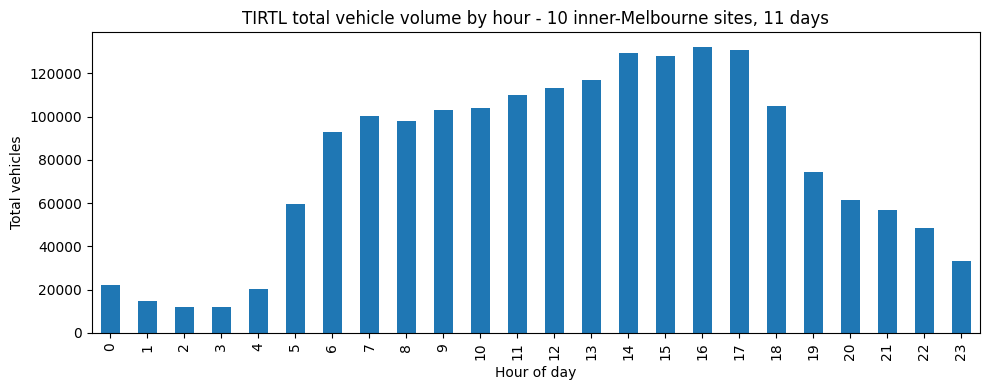

In [7]:
hourly_tirtl = tirtl.copy()
hourly_tirtl["hour"] = hourly_tirtl["time_bin"].str.split(":").str[0].astype(int)
hourly_profile = hourly_tirtl.groupby("hour")["volume"].sum()

fig, ax = plt.subplots()
hourly_profile.plot(kind="bar", ax=ax)
ax.set_title(f"TIRTL total vehicle volume by hour - {len(tirtl_sites)} inner-Melbourne sites, {tirtl['date'].nunique()} days")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Total vehicles")
plt.tight_layout()
plt.show()


In [8]:
print("Speed bin distribution (top 10):")
print(tirtl.groupby("speed_bin")["volume"].sum().sort_values(ascending=False).head(10))


Speed bin distribution (top 10):
speed_bin
75km/hr to < 80km/hr    573832
70km/hr to < 75km/hr    412160
80km/hr to < 85km/hr    246058
65km/hr to < 70km/hr    230321
60km/hr to < 65km/hr    126545
55km/hr to < 60km/hr     77095
85km/hr to < 90km/hr     55311
50km/hr to < 55km/hr     48353
45km/hr to < 50km/hr     31596
40km/hr to < 45km/hr     23316
Name: volume, dtype: int64


**Finding:** with only 10 inner-Melbourne TIRTL sites (these are freeway/arterial-style sensors,
not intersection-level like SCATS), coverage is sparse but shows a plausible commuter-hour profile
and a speed distribution concentrated in the 75-100km/h range - consistent with these being
higher-speed arterial/freeway sites rather than local streets, which fits TIRTL's role as a
complement to SCATS (higher-speed corridor context) rather than a replacement for it.


## 3. Telemetry Traffic Counts - coverage check

In [9]:
telemetry_files = sorted(glob.glob(str(RAW_DIR / "telemetry_extracted" / "*.csv")))
telemetry_inner = pd.read_csv(PROCESSED_DIR / "telemetry_inner_melbourne_sites.csv")
print(f"Telemetry inner-Melbourne sites: {len(telemetry_inner)} (confirmed 0 in 00_data_ingestion.ipynb)")
print(f"{len(telemetry_files)} daily telemetry files available for August 2026.")

telemetry_all = pd.concat([pd.read_csv(f) for f in telemetry_files], ignore_index=True)
print(f"Total telemetry rows (statewide): {len(telemetry_all):,}, across {telemetry_all['site'].nunique()} sites")


Telemetry inner-Melbourne sites: 0 (confirmed 0 in 00_data_ingestion.ipynb)
3 daily telemetry files available for August 2026.


Total telemetry rows (statewide): 208,255, across 52 sites


In [10]:
print("Vehicle classification (statewide telemetry, all sites):")
print(telemetry_all.groupby("vehicle_class")["volume"].sum().sort_values(ascending=False).head(8))


Vehicle classification (statewide telemetry, all sites):
vehicle_class
4bin: 1.Short                     1135794
4bin: 2.Rigid                      105877
4bin: 3.Articulated                 40108
4bin: 4.Bdouble/HPFV                31928
12bin: 1.Short                      19649
Other                                2047
12bin: 3.Two Axle Truck or Bus       2007
12bin: 2.Short - Towing               708
Name: volume, dtype: int64


**Finding - confirmed dataset limitation:** Telemetry has **zero sites within the inner-Melbourne
study area** (nearest is ~21km from the CBD, per `00_data_ingestion.ipynb`). It is a heavy-vehicle
classification network for strategic/regional roads. Given the PO brief mentions the ~33
intervention sites span CBD, metro *and regional* bands, this dataset may still be useful for the
**regional** sites (e.g. Greater Geelong, Greater Dandenong corridors) once those exact locations
are confirmed - but it contributes nothing to the CBD-adjacent priority sites this Sprint 1 pass is
scoped to.


### Summary of findings
- Weather during this window (winter, Jul-Aug 2026) had measurable rain in ~11% of hours - a
  realistic confound to control for in a before/after comparison, available at hourly granularity to
  join against both the SCATS and parking pipelines by timestamp.
- TIRTL has thin but usable coverage (10 sites) in the study area, showing a commuter-hour profile
  and higher-speed characteristics consistent with its role as an arterial/freeway sensor network.
- **Telemetry has no coverage in the inner-Melbourne study area at all** - it's a strategic-road
  network better suited to the regional bands of the intervention site list, not the CBD-adjacent
  priority sites. This should be flagged to the team before anyone builds a pipeline assuming
  telemetry covers the core study area.
